In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## YOLO: A Brief History
1. YOLO (You Only Look Once), a popular object detection and image segmentation model, was developed by Joseph Redmon and Ali Farhadi at the University of Washington. Launched in 2015, YOLO quickly gained popularity for its high speed and accuracy.

2. YOLOv2, released in 2016, improved the original model by incorporating batch normalization, anchor boxes, and dimension clusters.
3. YOLOv3, launched in 2018, further enhanced the model's performance using a more efficient backbone network, multiple anchors and spatial pyramid pooling.
4. YOLOv4 was released in 2020, introducing innovations like Mosaic data augmentation, a new anchor-free detection head, and a new loss function.
5. YOLOv5 further improved the model's performance and added new features such as hyperparameter optimization, integrated experiment tracking and automatic export to popular export formats.
6. YOLOv6 was open-sourced by Meituan in 2022 and is in use in many of the company's autonomous delivery robots.
7. YOLOv7 added additional tasks such as pose estimation on the COCO keypoints dataset.
8. YOLOv8 is the latest version of YOLO by Ultralytics. As a cutting-edge, state-of-the-art (SOTA) model, YOLOv8 builds on the success of previous versions, introducing new features and improvements for enhanced performance, flexibility, and efficiency. YOLOv8 supports a full range of vision AI tasks, including detection, segmentation, pose estimation, tracking, and classification. This versatility allows users to leverage YOLOv8's capabilities across diverse applications and domains.
9. YOLOv9 Introduces innovative methods like Programmable Gradient Information (PGI) and the Generalized Efficient Layer Aggregation Network (GELAN).

# How to create labels and data?

*   INPUT is Image and Bounding Box GroundTruth Dataset==(Images+labels)
 
1. Image can be collected through photos, if vedio feed you extract frames and capture numberplate, manually or assign someone.
*   Now for the Bounding Box information, we have to manually pick image and draw box and find coordinates and save this labelling.

2.  Or the Autoamted way is to pass image to YOLO and let YOLO predict the BB(Bounding Box).

3. Or Go to RoboFLow Annotation and draw a BOunding Box on the image and then it will give you the Box Information(x,y,w,h) and you can download this label information for every image.

# Here about the Dataset currently we have

- we have the images and their Annotations in which we have
- folder,filename,w,h,depth,object,Xmin,Ymin,Xmax,Ymax
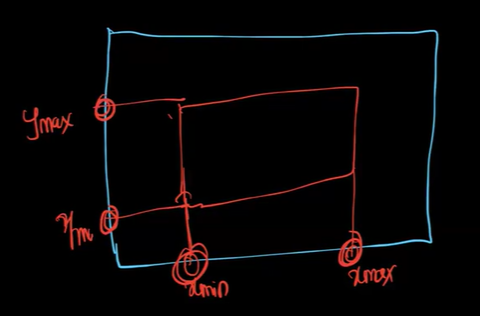
This above image is in format Pascal VOc format, we have to convert this into YOLO format.

- YOLO expects Xcenter,Ycenter, Width,Height
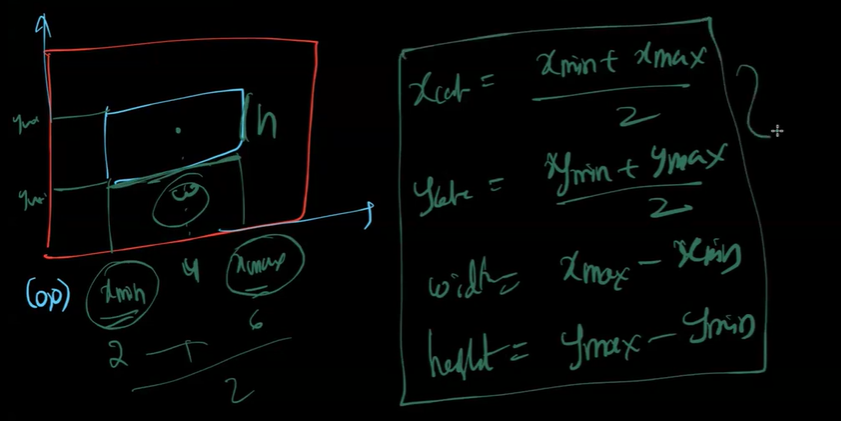

- YOLO expects the Input to be normalized, so we need to divide by pixels



In [10]:
# Imports
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet
from sklearn.model_selection import train_test_split

import torch

print(f"{torch.cuda.is_available()= }")
print(f'{torch.cuda.device_count()= } ')

torch.cuda.is_available()= True
torch.cuda.device_count()= 1 


For using YOLO we have to install ultrlytics

In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:0000:01


FOr visualizing whil training ipywidgets we need to install

In [13]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5


In [14]:
dataset_path='/kaggle/input/datasets/andrewmvd/car-plate-detection'

Now we will write a function to extract numbers from a given string via regex
for eg file124.txt i want 124 extracted

In [33]:
import re

def num_in_string(filename):
    match=re.search(r'(\d+)',filename) # d+ for finding the digits consecutive
    if match:
        return int(match.group(0)) #match.group will return the number part from the match
        # int because for sorting purposes we need number format
    else:
        return 0
print(num_in_string('/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars339.xml'))
        

339


Now we have .xml files we have to read those files and convert into text

In [48]:
labels_dict=dict(
    img_path=[],
    xmin=[],
    xmax=[],
    ymin=[],
    ymax=[],
    img_w=[],
    img_h=[]
)

In [22]:
labels_dict

{'img_path': [],
 'xmin': [],
 'xmax': [],
 'ymin': [],
 'ymax': [],
 'img_w': [],
 'img_h': []}

In [25]:
# the glob library will help us read the xml files path in the text
# the * means here read all the files containing the .xml extension
xml_files=glob(f"{dataset_path}/annotations/*.xml")
xml_files

['/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars339.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars13.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars74.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars16.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars291.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars236.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars429.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars132.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars251.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars51.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars165.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars313.xml',
 '/kaggle/input/datasets/andrewm

Now here in the annotatinos folder i want to read the files in the sorted way

Now we will import the xml tree for parsing the xml data

In [36]:
import xml.etree.ElementTree as xet

In [49]:
# Process each XML file, sorted by the numerical value in the filename
for filename in sorted(xml_files,key=num_in_string):
    # Parse the XML file
    info=xet.parse(filename)
    root = info.getroot()
    # Find the 'object' element in the XML and extract bounding box information
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)
    #print(xmin,xmax,ymin,ymax)
    
    # Get the image filename and construct the full path to the image
    img_name = root.find('filename').text
    img_path = os.path.join(dataset_path, 'images', img_name)
    #print(img_name,img_path)

    # Append the extracted information to the respective lists in the dictionary
    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)

    # Read the image via cv2 to get its shape which will be the width and height of image
    # Shape will give me three dimensions rgb in which first two are height width
    height, width, _ = cv2.imread(img_path).shape
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)
    #print(height,width)

    #print(labels_dict)
    #break
    

In [50]:
# Convert the dictionary to a pandas DataFrame
alldata = pd.DataFrame(labels_dict)

# Display the DataFrame
alldata

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/kaggle/input/datasets/andrewmvd/car-plate-det...,226,419,125,173,500,268
1,/kaggle/input/datasets/andrewmvd/car-plate-det...,134,262,128,160,400,248
2,/kaggle/input/datasets/andrewmvd/car-plate-det...,229,270,176,193,400,400
3,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,261,128,157,400,225
4,/kaggle/input/datasets/andrewmvd/car-plate-det...,156,503,82,253,590,350
...,...,...,...,...,...,...,...
428,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,258,128,157,400,225
429,/kaggle/input/datasets/andrewmvd/car-plate-det...,86,208,166,195,301,400
430,/kaggle/input/datasets/andrewmvd/car-plate-det...,38,116,159,197,400,225
431,/kaggle/input/datasets/andrewmvd/car-plate-det...,55,343,82,147,400,192


### So here we converted the XML info into Dataframe which is in good format for further calculations

### Now we will do the train test split

In [51]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
# Use 10% of the data for the test set
train, test = train_test_split(alldata, test_size=1/10, random_state=42)

# Split the training data further into training and validation sets
# Use 8/9 of the remaining data for the training set, resulting in an 80/10/10 split overall
train, val = train_test_split(train, train_size=8/9, random_state=42)

# Print the number of samples in each set
print(f'''
      len(train) = {len(train)}
      len(val) = {len(val)}
      len(test) = {len(test)}
''')



      len(train) = 345
      len(val) = 44
      len(test) = 44



In [52]:
train.head()

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
124,/kaggle/input/datasets/andrewmvd/car-plate-det...,305,320,256,267,400,267
315,/kaggle/input/datasets/andrewmvd/car-plate-det...,12,385,98,181,400,300
282,/kaggle/input/datasets/andrewmvd/car-plate-det...,37,319,145,203,350,263
236,/kaggle/input/datasets/andrewmvd/car-plate-det...,223,250,106,119,400,176
112,/kaggle/input/datasets/andrewmvd/car-plate-det...,49,164,135,191,240,400


### Now we will have to convert this image into YOLO format and save it in text file.So YOLO expects the data in text format